# Classification and Evaluation in NLP

**Text classification** is a common Natural Language Processing (NLP) task where a model assigns a predefined category or label to a piece of text.

Examples include:
- Spam detection
- Sentiment analysis
- News categorization

In this lab, we will learn how to build and evaluate a text classification model.

## Case Study: Sentiment Analysis

Sentiment analysis, also known as opinion mining, its goal is to understand the information present in the text and categorize it as positive, negative, or neutral.

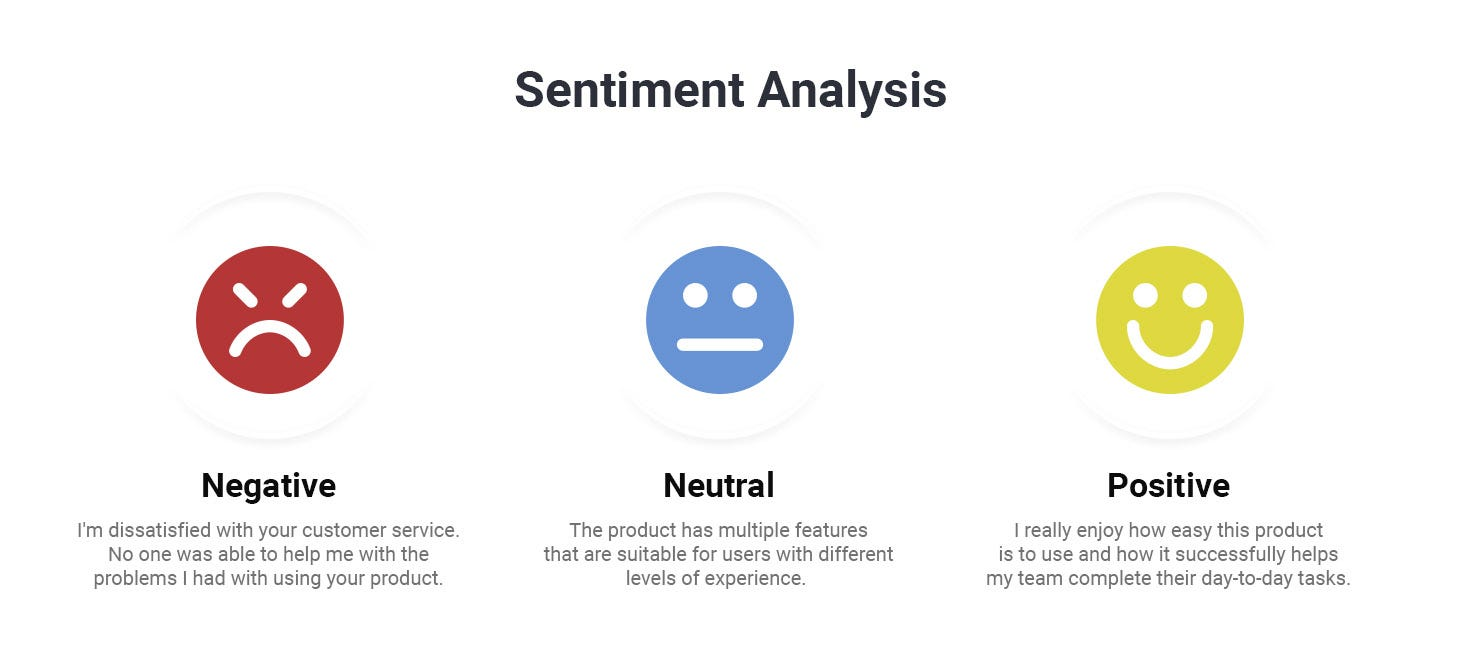

# Use Case:  Amazon reviews of unlocked phone analysis

The objective of this use case is to conduct sentiment analysis on Amazon reviews of unlocked phones, categorizing reviews into three classes: positive, negative, and neutral. The goal is to gain a comprehensive understanding of customer opinions and sentiments regarding various unlocked phone models.

- Dataset link: https://www.kaggle.com/datasets/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

Task1: Load the data and do 5 different preprocessing steps on it

Task2: Use a proper train and test split

Task3: Do Feature Extraction Using TF-IDF

Task4: Train a Naive Bayes Classifier

Task5: Evaluate the model on the Test Set

Task6: Print the Confusion Matrix

In [2]:
# ============================================
# Task 1: Load the data and preprocess the text
# ============================================

import pandas as pd
import re
import glob
import os

# Path to the folder containing the dataset
folder_path = r"C:\Users\saraf\Downloads"

# Find CSV files in the folder
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

print("CSV files found:")
for file in csv_files:
    print(os.path.basename(file))

# Find the Amazon dataset
amazon_files = [file for file in csv_files if "Amazon" in os.path.basename(file)]

if len(amazon_files) == 0:
    raise FileNotFoundError("No Amazon CSV dataset was found in the Downloads folder.")

# Load the first matching Amazon CSV file
file_path = amazon_files[0]
data = pd.read_csv(file_path, encoding='latin-1')

print("\nDataset loaded successfully!")
print("File:", os.path.basename(file_path))
print("Dataset shape:", data.shape)

# Display column names
print("\nColumns:")
print(data.columns.tolist())

# Remove rows with missing review text or rating
data = data.dropna(subset=['Reviews', 'Rating']).copy()

# Convert Rating to numeric
data['Rating'] = pd.to_numeric(data['Rating'], errors='coerce')

# Remove rows where Rating could not be converted
data = data.dropna(subset=['Rating']).copy()

# Create sentiment labels from the ratings
data['Sentiment'] = data['Rating'].apply(
    lambda rating: 'positive' if rating > 3
    else ('negative' if rating < 3 else 'neutral')
)

# --------------------------------------------
# Preprocessing function
# --------------------------------------------

def preprocess_text(text):

    # 1. Convert text to lowercase
    text = text.lower()

    # 2. Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text)

    # 4. Tokenize the text
    words = text.split()

    # 5. Remove very short tokens
    words = [word for word in words if len(word) > 1]

    return ' '.join(words)

# Apply preprocessing
data['Reviews'] = data['Reviews'].apply(preprocess_text)

# Remove empty reviews after preprocessing
data = data[data['Reviews'].str.strip() != ''].copy()

# Display the cleaned data
print("\nCleaned data:")
display(data[['Reviews', 'Rating', 'Sentiment']].head())

print("\nFinal dataset shape:", data.shape)

# Show sentiment distribution
print("\nSentiment distribution:")
print(data['Sentiment'].value_counts())

CSV files found:
Amazon_Unlocked_Mobile.csv
Chocolate_Sales.csv
Random Tweets from Pakistan- Cleaned- Anonymous.csv
Student Mental health.csv
water_potability (1).csv
water_potability.csv

Dataset loaded successfully!
File: Amazon_Unlocked_Mobile.csv
Dataset shape: (413840, 6)

Columns:
['Product Name', 'Brand Name', 'Price', 'Rating', 'Reviews', 'Review Votes']

Cleaned data:


,Reviews,Rating,Sentiment
0,feel so lucky to have found this used phone to...,5,positive
1,nice phone nice up grade from my pantach revue...,4,positive
2,very pleased,5,positive
3,it works good but it goes slow sometimes but i...,4,positive
4,great phone to replace my lost phone the only ...,4,positive



Final dataset shape: (412804, 7)

Sentiment distribution:
Sentiment
positive    284038
negative     97030
neutral      31736
Name: count, dtype: int64


In [3]:
# ============================================
# Task 2: Train/Test Split
# ============================================

from sklearn.model_selection import train_test_split

# Features and labels
X = data['Reviews']
y = data['Sentiment']

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the sizes
print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

print("\nTraining label distribution:")
print(y_train.value_counts())

print("\nTesting label distribution:")
print(y_test.value_counts())

Training data size: (330243,)
Testing data size: (82561,)

Training label distribution:
Sentiment
positive    227230
negative     77624
neutral      25389
Name: count, dtype: int64

Testing label distribution:
Sentiment
positive    56808
negative    19406
neutral      6347
Name: count, dtype: int64


In [4]:
# ============================================
# Task 3: Feature Extraction Using TF-IDF
# ============================================

from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000
)

# Fit TF-IDF only on the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform the test data using the same fitted vectorizer
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Display the results
print("TF-IDF feature extraction completed!")

print("\nTraining TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

print("\nNumber of features:", len(tfidf_vectorizer.get_feature_names_out()))

# Display some of the extracted features
print("\nFirst 20 TF-IDF features:")
print(tfidf_vectorizer.get_feature_names_out()[:20])

TF-IDF feature extraction completed!

Training TF-IDF shape: (330243, 5000)
Testing TF-IDF shape: (82561, 5000)

Number of features: 5000

First 20 TF-IDF features:
['abilities' 'ability' 'able' 'about' 'above' 'abroad' 'absolute'
 'absolutely' 'abuse' 'ac' 'accept' 'acceptable' 'accepted' 'accepting'
 'accepts' 'accesories' 'accesorios' 'access' 'accessibility' 'accessible']


In [5]:
# ============================================
# Task 4: Train a Naive Bayes Classifier
# ============================================

from sklearn.naive_bayes import MultinomialNB

# Create the Naive Bayes classifier
nb_classifier = MultinomialNB()

# Train the classifier
nb_classifier.fit(X_train_tfidf, y_train)

print("Naive Bayes classifier trained successfully!")

Naive Bayes classifier trained successfully!


In [6]:
# ============================================
# Task 5: Evaluate the Model
# ============================================

from sklearn.metrics import accuracy_score, classification_report

# Make predictions on the test set
predictions = nb_classifier.predict(X_test_tfidf)

# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)

print(f"Accuracy: {accuracy:.4f}")

# Display classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        predictions,
        labels=['negative', 'neutral', 'positive'],
        zero_division=0
    )
)

Accuracy: 0.8409

Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.74      0.77     19406
     neutral       0.37      0.03      0.06      6347
    positive       0.86      0.97      0.91     56808

    accuracy                           0.84     82561
   macro avg       0.67      0.58      0.58     82561
weighted avg       0.81      0.84      0.81     82561



Confusion Matrix:
[[14287   108  5011]
 [ 1961   217  4169]
 [ 1617   268 54923]]


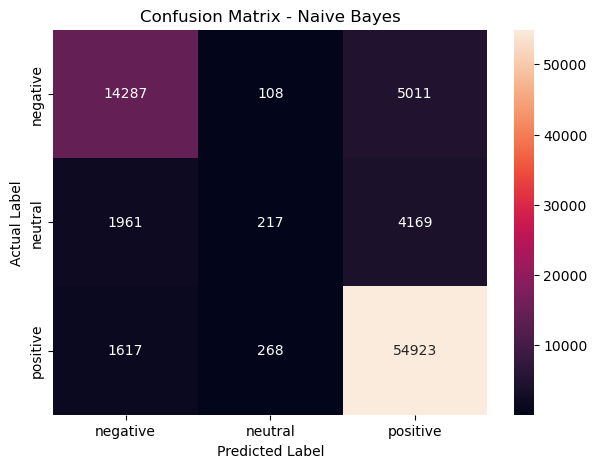

In [8]:
# ============================================
# Task 6: Confusion Matrix
# ============================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define the order of the classes
labels = ['negative', 'neutral', 'positive']

# Calculate the confusion matrix
cm = confusion_matrix(
    y_test,
    predictions,
    labels=labels
)

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)

# Display the confusion matrix as a heatmap
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()